In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression

In [ ]:
#load dataset
df=pd.read_csv("/content/heart_2022_with_nans.csv")
print("Dataset loaded")

Dataset loaded


In [ ]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,309318.000000,310652.000000,313308.000000,296771.000000,287379.000000,282467.000000
mean,4.319257,4.393157,7.015662,1.702891,83.026584,28.506480
std,8.663473,8.400344,1.507513,0.107131,21.487055,6.556341
min,0.000000,0.000000,1.000000,0.910000,22.680000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.080000
50%,0.000000,0.000000,7.000000,1.700000,80.740000,27.410000
75%,3.000000,5.000000,8.000000,1.780000,95.250000,31.660000
max,30.000000,30.000000,24.000000,2.410000,292.570000,99.340000


In [ ]:
df.shape

(317186, 40)

In [ ]:
#identify duplicate records
df.duplicated().sum()

np.int64(111)

In [ ]:
#remove duplicate records
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#identify null values
df.isnull().sum()

,0
State,0
Sex,1
GeneralHealth,862
PhysicalHealthDays,7864
MentalHealthDays,6530
LastCheckupTime,5980
PhysicalActivities,788
SleepHours,3874
RemovedTeeth,8471
HadHeartAttack,2265


In [ ]:
#find missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

Sex                              1
GeneralHealth                  862
PhysicalHealthDays            7864
MentalHealthDays              6530
LastCheckupTime               5980
PhysicalActivities             788
SleepHours                    3874
RemovedTeeth                  8471
HadHeartAttack                2265
HadAngina                     3247
HadStroke                     1144
HadAsthma                     1256
HadSkinCancer                 2308
HadCOPD                       1630
HadDepressiveDisorder         2016
HadKidneyDisease              1408
HadArthritis                  1921
HadDiabetes                    805
DeafOrHardOfHearing          14574
BlindOrVisionDifficulty      15236
DifficultyConcentrating      17154
DifficultyWalking            17066
DifficultyDressingBathing    17010
DifficultyErrands            18262
SmokerStatus                 25376
ECigaretteUsage              25520
ChestScan                    40098
RaceEthnicityCategory        10137
AgeCategory         

In [ ]:
target_col = 'HadHeartAttack'

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
if target_col in categorical_cols:
    categorical_cols.remove(target_col)


In [ ]:
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
df.isnull().sum()

,0
State,0
Sex,0
GeneralHealth,0
PhysicalHealthDays,0
MentalHealthDays,0
LastCheckupTime,0
PhysicalActivities,0
SleepHours,0
RemovedTeeth,0
HadHeartAttack,0


In [ ]:
#label encodig
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
#onehot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df.head()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HadHeartAttack,HeightInMeters,WeightInKilograms,BMI,State_1,State_2,State_3,...,AlcoholDrinkers_1,HIVTesting_1,FluVaxLast12_1,PneumoVaxEver_1,TetanusLast10Tdap_1,TetanusLast10Tdap_2,TetanusLast10Tdap_3,HighRiskLastYear_1,CovidPos_1,CovidPos_2
0,0.0,0.0,8.0,0,1.70,80.74,27.41,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,0.0,0.0,6.0,0,1.60,68.04,26.57,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2.0,3.0,5.0,0,1.57,63.50,25.61,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.0,0.0,7.0,0,1.65,63.50,23.30,False,False,False,...,False,False,True,True,False,False,False,False,False,False
4,2.0,0.0,9.0,0,1.57,53.98,21.77,False,False,False,...,True,False,False,True,False,False,False,False,False,False


In [ ]:
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].map({'No': 0, 'Yes': 1})


In [ ]:
X = pd.get_dummies(df.drop(columns=[target_col]), columns=categorical_cols, drop_first=True)
y = df[target_col]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression

#model building
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
print("Model Classification Report")
print(classification_report(y_test, y_pred))


=== Model Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     59372
           1       0.22      0.77      0.34      3590

    accuracy                           0.83     62962
   macro avg       0.60      0.80      0.62     62962
weighted avg       0.94      0.83      0.87     62962



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[49452  9920]
 [  842  2748]]


In [ ]:
plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

In [ ]:
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

ROC AUC Score: 0.8830


Text(0.5, 1.0, 'Confusion Matrix Topology')

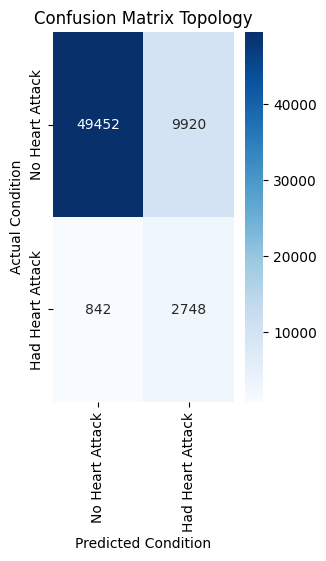

In [ ]:
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Attack', 'Had Heart Attack'],
            yticklabels=['No Heart Attack', 'Had Heart Attack'])
plt.xlabel("Predicted Condition")
plt.ylabel("Actual Condition")
plt.title("Confusion Matrix Topology")

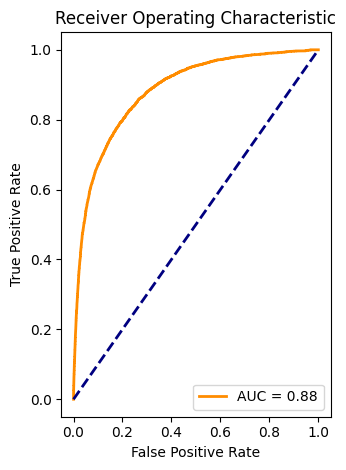

In [ ]:
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()